In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Carga del dataset de datos de la gripe

In [2]:
data=pd.read_csv("./FLU WHO/VIW_FNT.csv", sep=",")
flu_ESP=data[(data.COUNTRY_AREA_TERRITORY=='Spain')&(data.ISO_YEAR>=2008)&(data.ORIGIN_SOURCE=='SENTINEL')]
flu_ESP['Fecha']=pd.to_datetime(flu_ESP['ISO_WEEKSTARTDATE'])-timedelta(days=1)
flu_ESP.INF_A=flu_ESP.INF_A.fillna(0)
flu_ESP.INF_B=flu_ESP.INF_B.fillna(0)
flu_ESP.INF_ALL=flu_ESP.INF_ALL.fillna(flu_ESP.INF_A+flu_ESP.INF_B)
flu_ESP=flu_ESP.loc[:,['INF_ALL','Fecha']]
flu_ESP.set_index('Fecha',inplace=True)
#flu_ESP

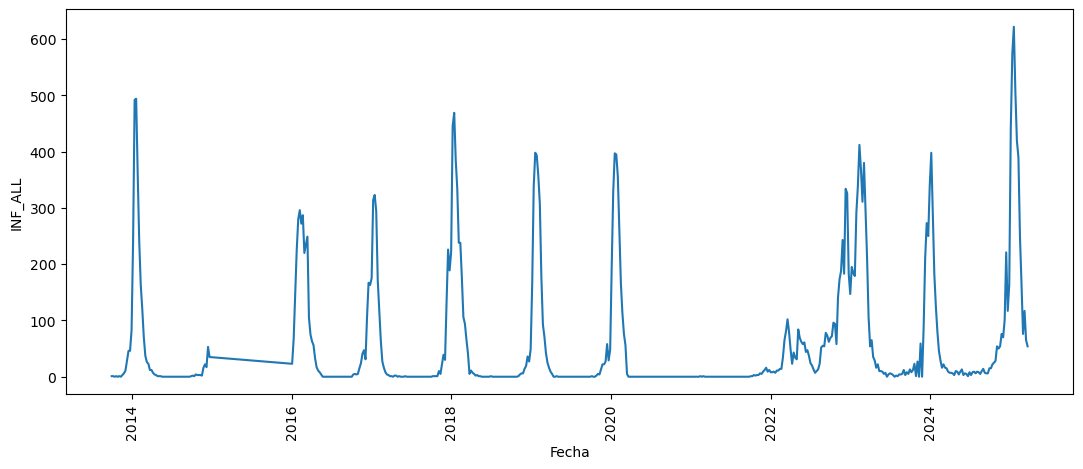

In [3]:
plt.figure(figsize=(13,5))
sns.lineplot(data=flu_ESP,x=flu_ESP.index,y=flu_ESP.INF_ALL)
plt.xticks(rotation=90)
plt.show()

### Temperatura media semanal en España

In [4]:
#Retiro Madrid
data=pd.read_csv("./tiempo/Spain/TG_MADRID_RETIRO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_retiro=df.resample('W').mean()

#Badajoz aeropuerto
data=pd.read_csv("./tiempo/Spain/TG_BADAJOZ_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_badajoz=df.resample('W').mean()

#Estacion de Tortosa
data=pd.read_csv("./tiempo/Spain/TG_MALAGA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_tortosa=df.resample('W').mean()

#Malaga Aeropuerto
data=pd.read_csv("./tiempo/Spain/TG_ESTACION_DE_TORTOSA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_malaga=df.resample('W').mean()

#Puerto de Navacerrada
data=pd.read_csv("./tiempo/Spain/TG_PUERTO_DE_NAVACERRADA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_navacerrada=df.resample('W').mean()

#Salamanca Aeropuerto
data=pd.read_csv("./tiempo/Spain/TG_SALAMANCA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_salamanca=df.resample('W').mean()

#San Sebastian
data=pd.read_csv("./tiempo/Spain/TG_SAN_SEBASTIAN.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_san_sebastian=df.resample('W').mean()

#Zaragoza Aeropuerto
data=pd.read_csv("./tiempo/Spain/TG_ZARAGOZA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_zaragoza=df.resample('W').mean()

#Valencia
data=pd.read_csv("./tiempo/Spain/TG_VALENCIA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_valencia=df.resample('W').mean()

df_concat = pd.concat([df_retiro, df_badajoz,df_tortosa, df_malaga,df_salamanca,
                       df_navacerrada,df_san_sebastian,df_zaragoza,df_valencia], axis=0)
df_media_TG = df_concat.groupby(level=0).mean()
#df_media_TG

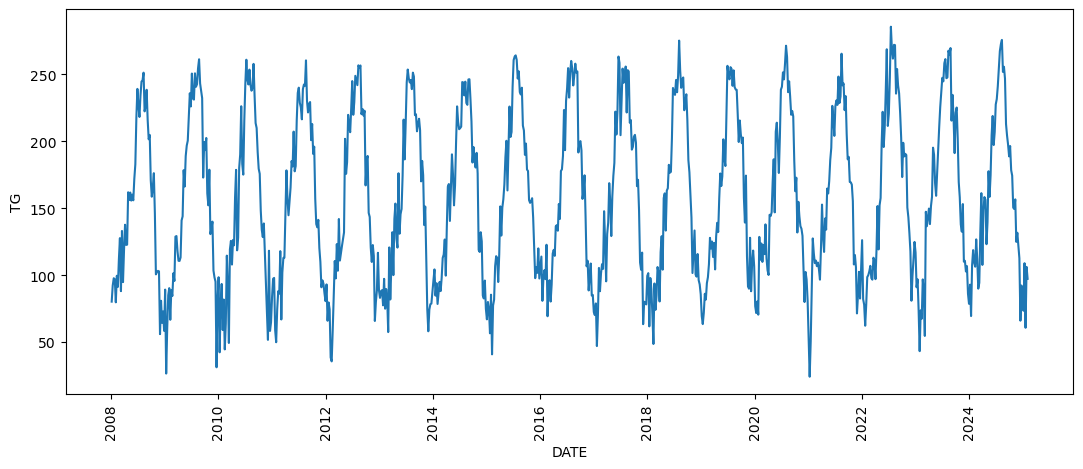

In [5]:
plt.figure(figsize=(13,5))
sns.lineplot(data=df_media_TG,x=df_media_TG.index,y=df_media_TG.TG)
plt.xticks(rotation=90)
plt.show()

### Humedad media semanal en España

In [6]:
#Retiro Madrid
data=pd.read_csv("./tiempo/Spain/HU_MADRID_RETIRO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_retiro=df.resample('W').mean()

#Badajoz aeropuerto
data=pd.read_csv("./tiempo/Spain/HU_BADAJOZ_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_badajoz=df.resample('W').mean()

#Estacion de Tortosa
data=pd.read_csv("./tiempo/Spain/HU_MALAGA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_tortosa=df.resample('W').mean()

#Malaga Aeropuerto
data=pd.read_csv("./tiempo/Spain/HU_ESTACION_DE_TORTOSA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_malaga=df.resample('W').mean()

#Puerto de Navacerrada
data=pd.read_csv("./tiempo/Spain/HU_PUERTO_DE_NAVACERRADA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_navacerrada=df.resample('W').mean()

#Salamanca Aeropuerto
data=pd.read_csv("./tiempo/Spain/HU_SALAMANCA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_salamanca=df.resample('W').mean()

#San Sebastian
data=pd.read_csv("./tiempo/Spain/HU_SAN_SEBASTIAN.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_san_sebastian=df.resample('W').mean()

#Zaragoza Aeropuerto
data=pd.read_csv("./tiempo/Spain/HU_ZARAGOZA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_zaragoza=df.resample('W').mean()

#Valencia
data=pd.read_csv("./tiempo/Spain/HU_VALENCIA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_valencia=df.resample('W').mean()

df_concat = pd.concat([df_retiro, df_badajoz,df_tortosa, df_malaga,df_salamanca,
                       df_navacerrada,df_san_sebastian,df_zaragoza,df_valencia], axis=0)
df_media_HU = df_concat.groupby(level=0).mean()
#df_media_HU

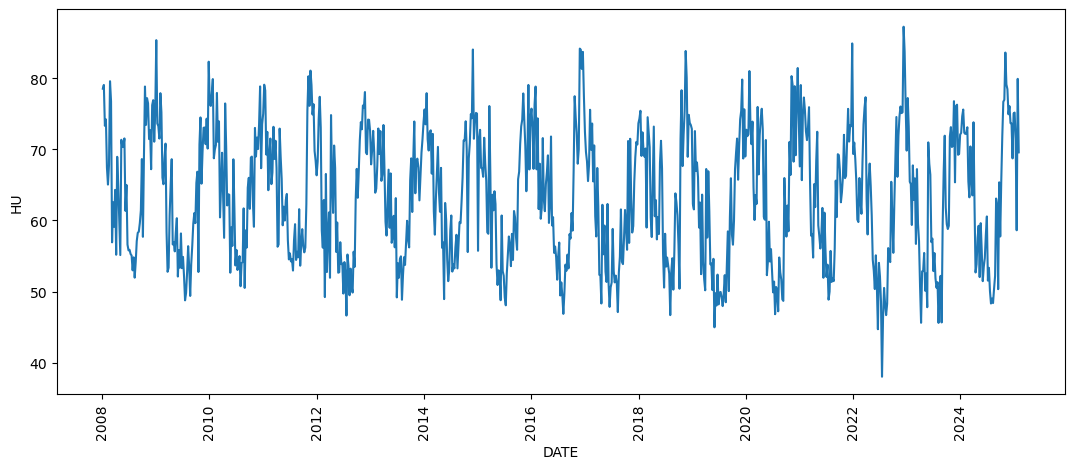

In [7]:
plt.figure(figsize=(13,5))
sns.lineplot(data=df_media_HU,x=df_media_HU.index,y=df_media_HU.HU)
plt.xticks(rotation=90)
plt.show()

### Precipitaciones medias semanales en España 

In [8]:
#Retiro Madrid
data=pd.read_csv("./tiempo/Spain/RR_MADRID_RETIRO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_retiro=df.resample('W').mean()

#Badajoz aeropuerto
data=pd.read_csv("./tiempo/Spain/RR_BADAJOZ_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_badajoz=df.resample('W').mean()

#Estacion de Tortosa
data=pd.read_csv("./tiempo/Spain/RR_MALAGA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_tortosa=df.resample('W').mean()

#Malaga Aeropuerto
data=pd.read_csv("./tiempo/Spain/RR_ESTACION_DE_TORTOSA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_malaga=df.resample('W').mean()

#Puerto de Navacerrada
data=pd.read_csv("./tiempo/Spain/RR_PUERTO_DE_NAVACERRADA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_navacerrada=df.resample('W').mean()

#Salamanca Aeropuerto
data=pd.read_csv("./tiempo/Spain/RR_SALAMANCA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_salamanca=df.resample('W').mean()

#San Sebastian
data=pd.read_csv("./tiempo/Spain/RR_SAN_SEBASTIAN.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_san_sebastian=df.resample('W').mean()

#Zaragoza Aeropuerto
data=pd.read_csv("./tiempo/Spain/RR_ZARAGOZA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_zaragoza=df.resample('W').mean()

#Valencia
data=pd.read_csv("./tiempo/Spain/RR_VALENCIA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_valencia=df.resample('W').mean()

df_concat = pd.concat([df_retiro, df_badajoz,df_tortosa, df_malaga,df_salamanca,
                       df_navacerrada,df_san_sebastian,df_zaragoza,df_valencia], axis=0)
df_media_RR = df_concat.groupby(level=0).mean()
#df_media_RR

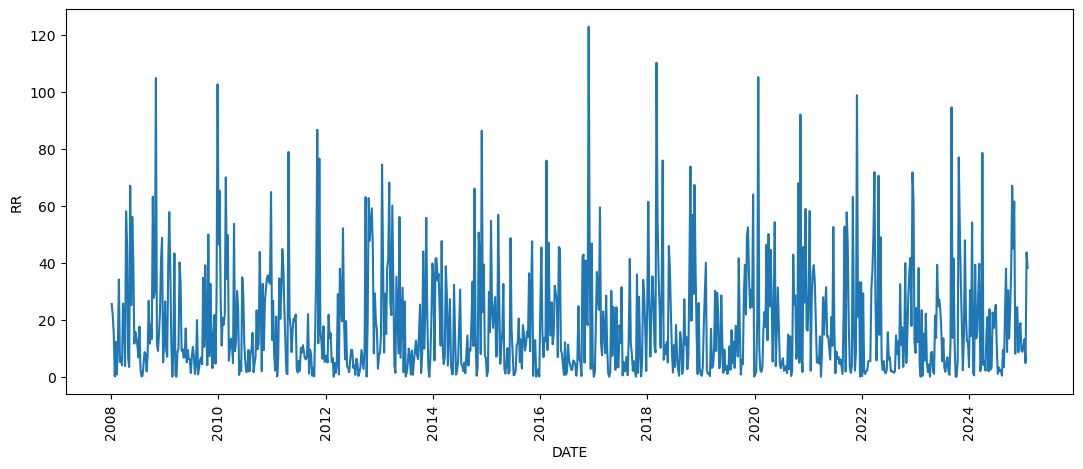

In [9]:
plt.figure(figsize=(13,5))
sns.lineplot(data=df_media_RR,x=df_media_RR.index,y=df_media_RR.RR)
plt.xticks(rotation=90)
plt.show()

### Fuerza media semanal del viento en España

In [10]:
#Retiro Madrid
data=pd.read_csv("./tiempo/Spain/FG_MADRID_RETIRO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_retiro=df.resample('W').mean()

#Badajoz aeropuerto
data=pd.read_csv("./tiempo/Spain/FG_BADAJOZ_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_badajoz=df.resample('W').mean()

#Estacion de Tortosa
data=pd.read_csv("./tiempo/Spain/FG_MALAGA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_tortosa=df.resample('W').mean()

#Malaga Aeropuerto
data=pd.read_csv("./tiempo/Spain/FG_ESTACION_DE_TORTOSA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_malaga=df.resample('W').mean()

#Puerto de Navacerrada
data=pd.read_csv("./tiempo/Spain/FG_PUERTO_DE_NAVACERRADA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_navacerrada=df.resample('W').mean()

#Salamanca Aeropuerto
data=pd.read_csv("./tiempo/Spain/FG_SALAMANCA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_salamanca=df.resample('W').mean()

#San Sebastian
data=pd.read_csv("./tiempo/Spain/FG_SAN_SEBASTIAN.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_san_sebastian=df.resample('W').mean()

#Zaragoza Aeropuerto
data=pd.read_csv("./tiempo/Spain/FG_ZARAGOZA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_zaragoza=df.resample('W').mean()

#Valencia
data=pd.read_csv("./tiempo/Spain/FG_VALENCIA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_valencia=df.resample('W').mean()

df_concat = pd.concat([df_retiro, df_badajoz,df_tortosa, df_malaga,df_salamanca,
                       df_navacerrada,df_san_sebastian,df_zaragoza,df_valencia], axis=0)
df_media_FG = df_concat.groupby(level=0).mean()
#df_media_FG

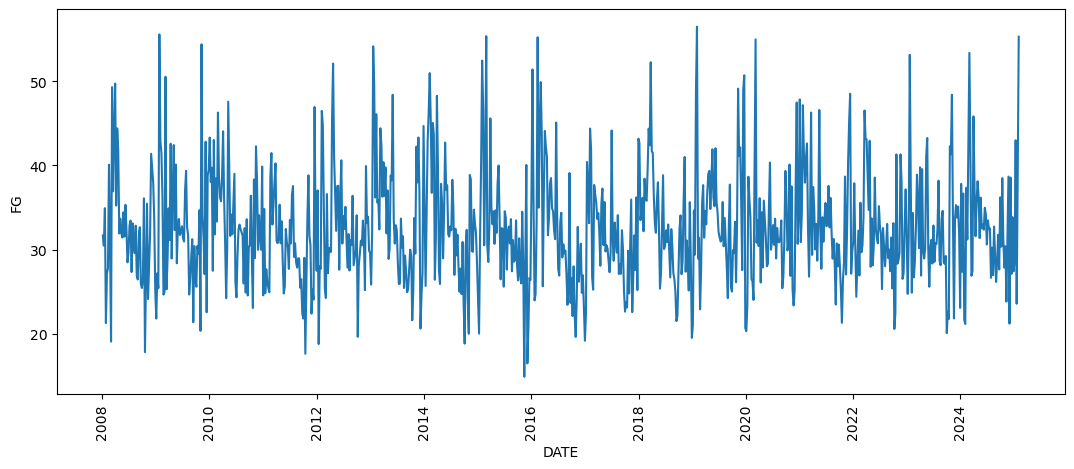

In [11]:
plt.figure(figsize=(13,5))
sns.lineplot(data=df_media_FG,x=df_media_FG.index,y=df_media_FG.FG)
plt.xticks(rotation=90)
plt.show()

### Unificación de dataframes

In [12]:
met=pd.concat([df_media_TG,df_media_HU,df_media_RR,df_media_FG],axis=1)
flu=pd.concat([flu_ESP,met],axis=1)
flu=flu.dropna()
flu

,INF_ALL,TG,HU,RR,FG
2013-09-29,1.0,216.857143,65.682540,16.206349,29.984127
2013-10-06,1.0,208.269841,68.738095,25.285714,29.206349
2013-10-13,0.0,170.111111,61.190476,1.285714,21.587302
2013-10-20,1.0,185.380952,68.619048,7.460317,25.063492
2013-10-27,0.0,174.761905,73.920635,43.920635,33.761905
...,...,...,...,...,...
2025-01-05,442.0,73.492063,75.174603,11.113228,28.714286
2025-01-12,574.0,108.984127,71.460317,13.174603,43.000000
2025-01-19,622.0,60.761905,58.619048,4.791005,23.555556
2025-01-26,506.0,106.222222,79.920635,43.611111,38.619048


In [13]:
#flu.to_csv('flu_esp_index.csv', index=True)

### Carga del dataset de datos de la Malaria 

In [14]:
dataMAL=pd.read_csv("./surveillance atlas (Hepatitis A, Nilo, Malaria)/ECDC_surveillance_data_Malaria.csv", sep=",")
dataMALRep=dataMAL[(dataMAL.Indicator=='Reported cases') & (dataMAL.RegionName=='Spain')]
dataMALRep['Time'] = pd.to_datetime(dataMALRep['Time'])
dataMALRep['NumValue'] = pd.to_numeric(dataMALRep['NumValue'])
dataMALRep=dataMALRep.loc[:,['Time','NumValue']]
dataMALRep.set_index('Time', inplace=True)
#dataMALRep

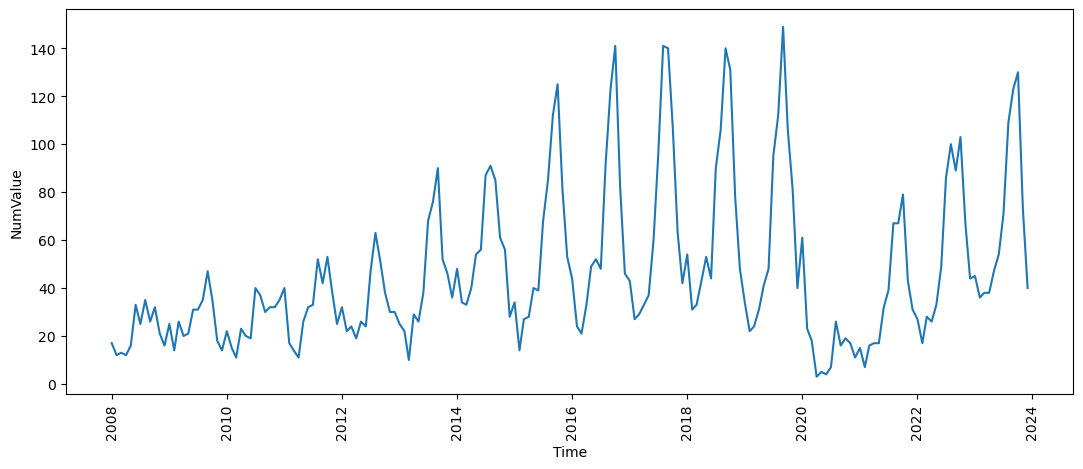

In [15]:
plt.figure(figsize=(13,5))
sns.lineplot(data=dataMALRep,x=dataMALRep.index,y=dataMALRep.NumValue)
plt.xticks(rotation=90)
plt.show()

### Datos de temperatura media en España

In [16]:
#Retiro Madrid
data=pd.read_csv("./tiempo/Spain/TG_MADRID_RETIRO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_retiro=df.resample('MS').mean()

#Badajoz aeropuerto
data=pd.read_csv("./tiempo/Spain/TG_BADAJOZ_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_badajoz=df.resample('MS').mean()

#Estacion de Tortosa
data=pd.read_csv("./tiempo/Spain/TG_MALAGA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_tortosa=df.resample('MS').mean()

#Malaga Aeropuerto
data=pd.read_csv("./tiempo/Spain/TG_ESTACION_DE_TORTOSA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_malaga=df.resample('MS').mean()

#Puerto de Navacerrada
data=pd.read_csv("./tiempo/Spain/TG_PUERTO_DE_NAVACERRADA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_navacerrada=df.resample('MS').mean()

#Salamanca Aeropuerto
data=pd.read_csv("./tiempo/Spain/TG_SALAMANCA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_salamanca=df.resample('MS').mean()

#San Sebastian
data=pd.read_csv("./tiempo/Spain/TG_SAN_SEBASTIAN.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_san_sebastian=df.resample('MS').mean()

#Zaragoza Aeropuerto
data=pd.read_csv("./tiempo/Spain/TG_ZARAGOZA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_zaragoza=df.resample('MS').mean()

#Valencia
data=pd.read_csv("./tiempo/Spain/TG_VALENCIA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_valencia=df.resample('MS').mean()

df_concat = pd.concat([df_retiro, df_badajoz,df_tortosa, df_malaga,df_salamanca,
                       df_navacerrada,df_san_sebastian,df_zaragoza,df_valencia], axis=0)
df_media_TG = df_concat.groupby(level=0).mean()
#df_media_TG

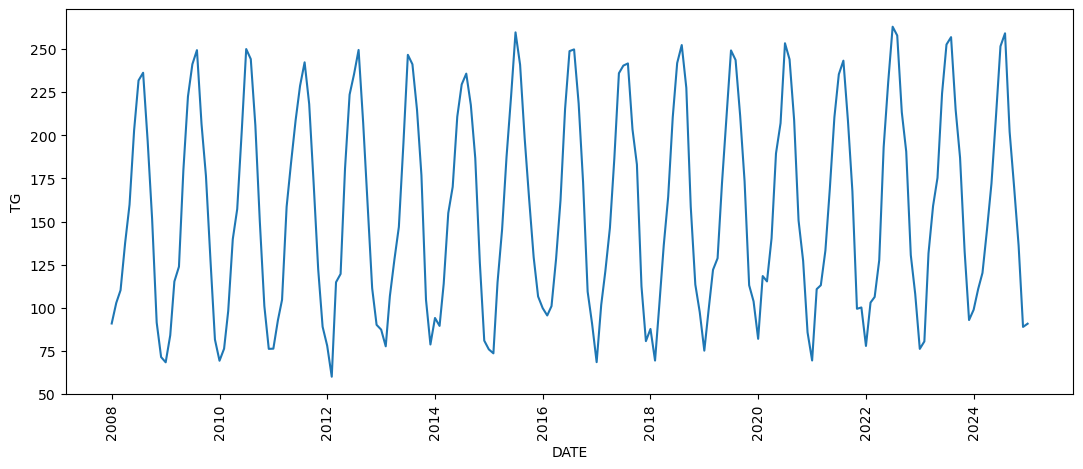

In [17]:
plt.figure(figsize=(13,5))
sns.lineplot(data=df_media_TG,x=df_media_TG.index,y=df_media_TG.TG)
plt.xticks(rotation=90)
plt.show()

### Humedad Media Mensual España

In [18]:
#Retiro Madrid
data=pd.read_csv("./tiempo/Spain/HU_MADRID_RETIRO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_retiro=df.resample('MS').mean()

#Badajoz aeropuerto
data=pd.read_csv("./tiempo/Spain/HU_BADAJOZ_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_badajoz=df.resample('MS').mean()

#Estacion de Tortosa
data=pd.read_csv("./tiempo/Spain/HU_MALAGA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_tortosa=df.resample('MS').mean()

#Malaga Aeropuerto
data=pd.read_csv("./tiempo/Spain/HU_ESTACION_DE_TORTOSA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_malaga=df.resample('MS').mean()

#Puerto de Navacerrada
data=pd.read_csv("./tiempo/Spain/HU_PUERTO_DE_NAVACERRADA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_navacerrada=df.resample('MS').mean()

#Salamanca Aeropuerto
data=pd.read_csv("./tiempo/Spain/HU_SALAMANCA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_salamanca=df.resample('MS').mean()

#San Sebastian
data=pd.read_csv("./tiempo/Spain/HU_SAN_SEBASTIAN.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_san_sebastian=df.resample('MS').mean()

#Zaragoza Aeropuerto
data=pd.read_csv("./tiempo/Spain/HU_ZARAGOZA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_zaragoza=df.resample('MS').mean()

#Valencia
data=pd.read_csv("./tiempo/Spain/HU_VALENCIA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_valencia=df.resample('MS').mean()

df_concat = pd.concat([df_retiro, df_badajoz,df_tortosa, df_malaga,df_salamanca,
                       df_navacerrada,df_san_sebastian,df_zaragoza,df_valencia], axis=0)
df_media_HU = df_concat.groupby(level=0).mean()
#df_media_HU

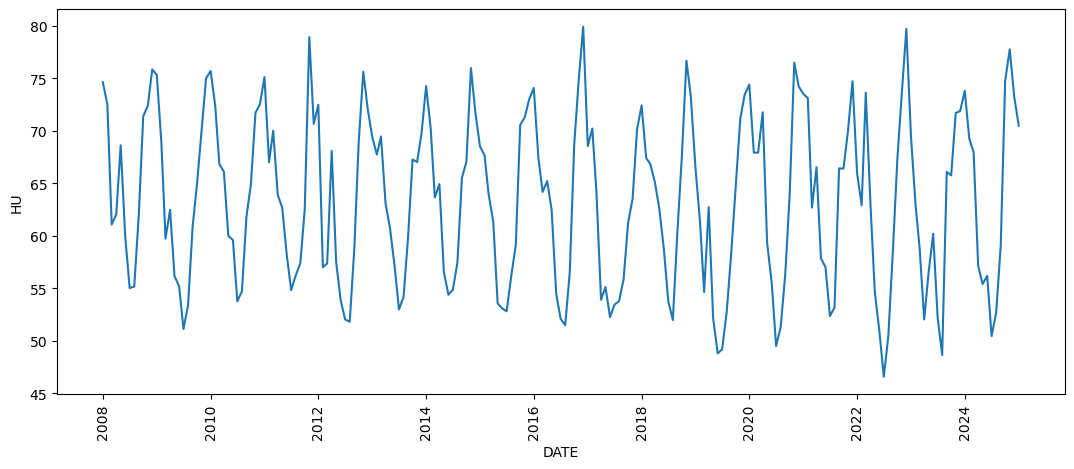

In [19]:
plt.figure(figsize=(13,5))
sns.lineplot(data=df_media_HU,x=df_media_HU.index,y=df_media_HU.HU)
plt.xticks(rotation=90)
plt.show()

### Precipitaciones Medias Mensual en España

In [20]:
#Retiro Madrid
data=pd.read_csv("./tiempo/Spain/RR_MADRID_RETIRO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_retiro=df.resample('MS').mean()

#Badajoz aeropuerto
data=pd.read_csv("./tiempo/Spain/RR_BADAJOZ_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_badajoz=df.resample('MS').mean()

#Estacion de Tortosa
data=pd.read_csv("./tiempo/Spain/RR_MALAGA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_tortosa=df.resample('MS').mean()

#Malaga Aeropuerto
data=pd.read_csv("./tiempo/Spain/RR_ESTACION_DE_TORTOSA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_malaga=df.resample('MS').mean()

#Puerto de Navacerrada
data=pd.read_csv("./tiempo/Spain/RR_PUERTO_DE_NAVACERRADA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_navacerrada=df.resample('MS').mean()

#Salamanca Aeropuerto
data=pd.read_csv("./tiempo/Spain/RR_SALAMANCA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_salamanca=df.resample('MS').mean()

#San Sebastian
data=pd.read_csv("./tiempo/Spain/RR_SAN_SEBASTIAN.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_san_sebastian=df.resample('MS').mean()

#Zaragoza Aeropuerto
data=pd.read_csv("./tiempo/Spain/RR_ZARAGOZA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_zaragoza=df.resample('MS').mean()

#Valencia
data=pd.read_csv("./tiempo/Spain/RR_VALENCIA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_valencia=df.resample('MS').mean()

df_concat = pd.concat([df_retiro, df_badajoz,df_tortosa, df_malaga,df_salamanca,
                       df_navacerrada,df_san_sebastian,df_zaragoza,df_valencia], axis=0)
df_media_RR = df_concat.groupby(level=0).mean()
#df_media_RR

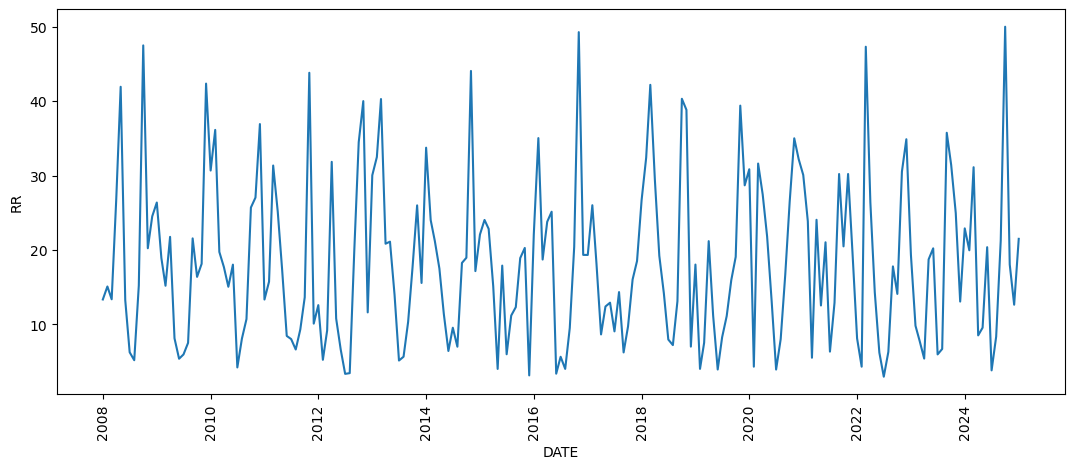

In [21]:
plt.figure(figsize=(13,5))
sns.lineplot(data=df_media_RR,x=df_media_RR.index,y=df_media_RR.RR)
plt.xticks(rotation=90)
plt.show()

### Fuerza Media del Viento en España Mensual

In [22]:
#Retiro Madrid
data=pd.read_csv("./tiempo/Spain/FG_MADRID_RETIRO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_retiro=df.resample('MS').mean()

#Badajoz aeropuerto
data=pd.read_csv("./tiempo/Spain/FG_BADAJOZ_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_badajoz=df.resample('MS').mean()

#Estacion de Tortosa
data=pd.read_csv("./tiempo/Spain/FG_MALAGA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_tortosa=df.resample('MS').mean()

#Malaga Aeropuerto
data=pd.read_csv("./tiempo/Spain/FG_ESTACION_DE_TORTOSA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_malaga=df.resample('MS').mean()

#Puerto de Navacerrada
data=pd.read_csv("./tiempo/Spain/FG_PUERTO_DE_NAVACERRADA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_navacerrada=df.resample('MS').mean()

#Salamanca Aeropuerto
data=pd.read_csv("./tiempo/Spain/FG_SALAMANCA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_salamanca=df.resample('MS').mean()

#San Sebastian
data=pd.read_csv("./tiempo/Spain/FG_SAN_SEBASTIAN.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_san_sebastian=df.resample('MS').mean()

#Zaragoza Aeropuerto
data=pd.read_csv("./tiempo/Spain/FG_ZARAGOZA_AEROPUERTO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_zaragoza=df.resample('MS').mean()

#Valencia
data=pd.read_csv("./tiempo/Spain/FG_VALENCIA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_valencia=df.resample('MS').mean()

df_concat = pd.concat([df_retiro, df_badajoz,df_tortosa, df_malaga,df_salamanca,
                       df_navacerrada,df_san_sebastian,df_zaragoza,df_valencia], axis=0)
df_media_FG = df_concat.groupby(level=0).mean()
#df_media_FG

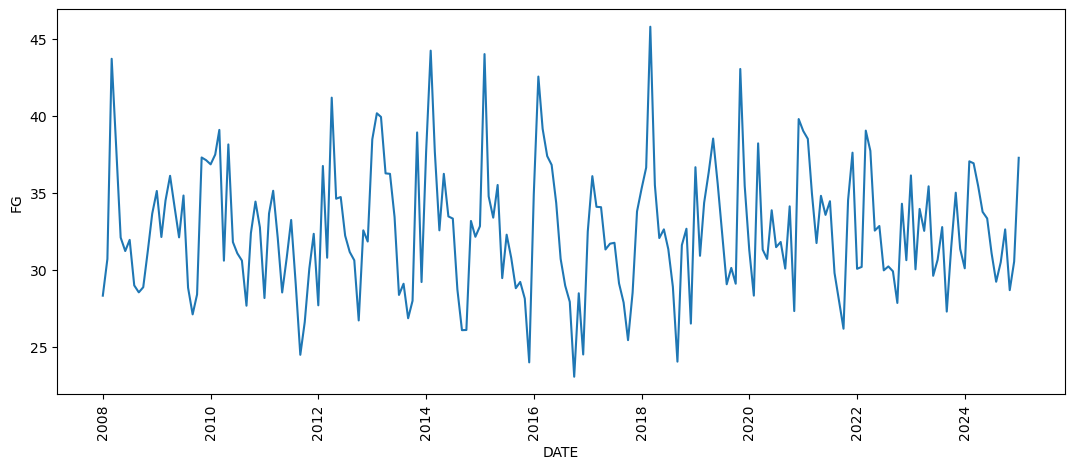

In [23]:
plt.figure(figsize=(13,5))
sns.lineplot(data=df_media_FG,x=df_media_FG.index,y=df_media_FG.FG)
plt.xticks(rotation=90)
plt.show()

### Unificación de dataframes

In [24]:
met=pd.concat([df_media_TG,df_media_HU,df_media_RR,df_media_FG],axis=1)
malaria=pd.concat([dataMALRep,met],axis=1)
malaria=malaria.dropna()
#malaria

In [25]:
#malaria.to_csv('malaria_esp_index.csv', index=True, encoding='utf-8')

### Carga del dataset de datos del virus del Nilo

In [26]:
data=pd.read_csv("./surveillance atlas (Hepatitis A, Nilo, Malaria)/ECDC_surveillance_data_West_Nile_virus_infection.csv", sep=",")
it=data[(data.Indicator=='Reported cases') & (data.RegionName=='Italy')]
it['Time'] = pd.to_datetime(it['Time'])
it['NumValue'] = pd.to_numeric(it['NumValue'])
it=it.loc[:,['NumValue','Time']]
it.set_index('Time', inplace=True)
#it

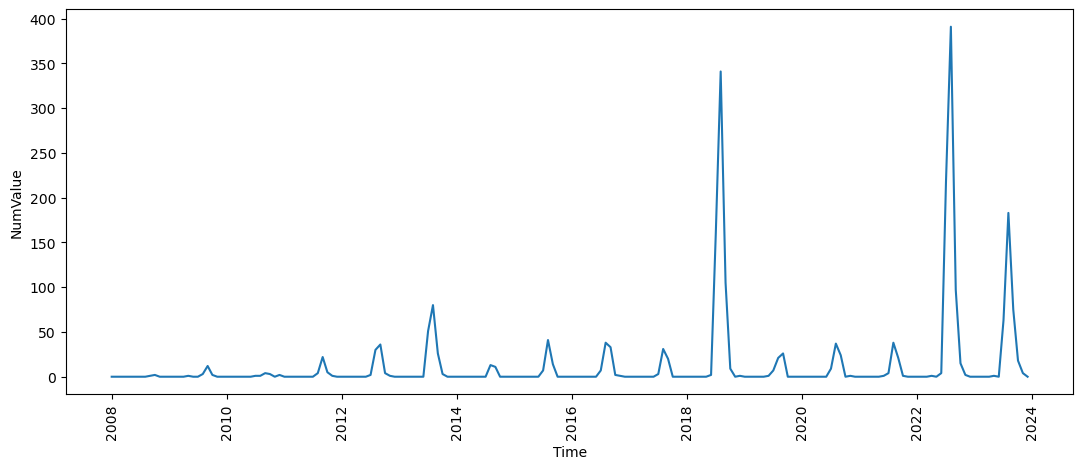

In [27]:
plt.figure(figsize=(13,5))
sns.lineplot(data=it,x=it.index,y=it.NumValue)
plt.xticks(rotation=90)
plt.show()

### Temperatura media mensual en Italia

In [28]:
#Ferrara
data=pd.read_csv("./tiempo/Italy/TG_FERRARA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_ferrara=df.resample('MS').mean()

#Roma Ciampino
data=pd.read_csv("./tiempo/Italy/TG_ROMA_CIAMPINO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_roma=df.resample('MS').mean()

#Bologna
data=pd.read_csv("./tiempo/Italy/TG_BOLOGNA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_bologna=df.resample('MS').mean()

#Milan
data=pd.read_csv("./tiempo/Italy/TG_MILAN.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_milan=df.resample('MS').mean()

#Brindisi
data=pd.read_csv("./tiempo/Italy/TG_BRINDISI.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_brindisi=df.resample('MS').mean()

#Cagliari
data=pd.read_csv("./tiempo/Italy/TG_CAGLIARI.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_cagliari=df.resample('MS').mean()

#Cagliari
data=pd.read_csv("./tiempo/Italy/TG_VERONA_VILLAFRANCA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
df=data.loc[:,['DATE','TG']]
dataW = df.set_index('DATE', inplace=True)
df_verona=df.resample('MS').mean()


df_concat = pd.concat([df_ferrara, df_roma, df_bologna, df_milan, df_brindisi, df_cagliari, df_verona], axis=0)
df_media_TG = df_concat.groupby(level=0).mean()
#df_media_TG

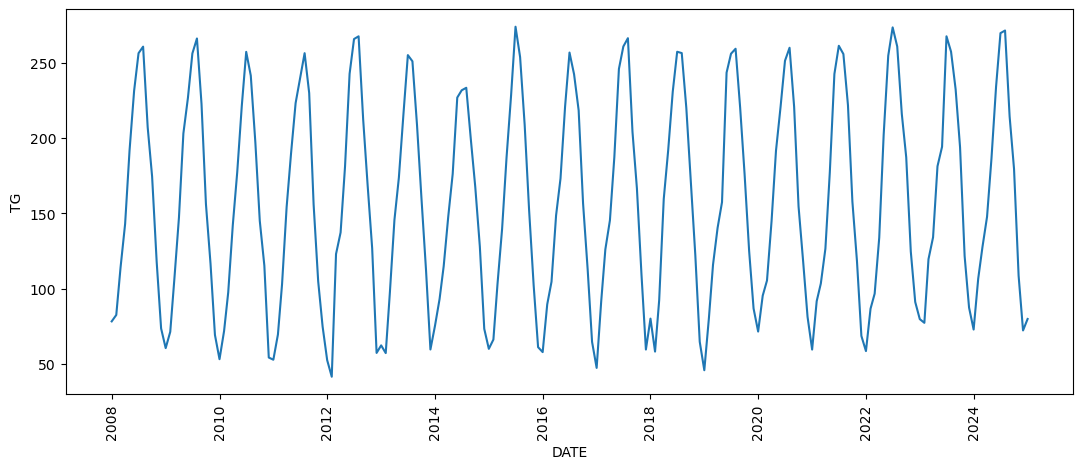

In [29]:
plt.figure(figsize=(13,5))
sns.lineplot(data=df_media_TG,x=df_media_TG.index,y=df_media_TG.TG)
plt.xticks(rotation=90)
plt.show()

### Humedad media mensual en Italia

In [30]:
#Ferrara
data=pd.read_csv("./tiempo/Italy/HU_FERRARA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_ferrara=df.resample('MS').mean()

#Roma Ciampino
data=pd.read_csv("./tiempo/Italy/HU_ROMA_CIAMPINO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_roma=df.resample('MS').mean()

#Brindisi
data=pd.read_csv("./tiempo/Italy/HU_Brindisi.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_brindisi=df.resample('MS').mean()

#Cagliari
data=pd.read_csv("./tiempo/Italy/HU_CAGLIARI.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_cagliari=df.resample('MS').mean()

#Verona Villafranca
data=pd.read_csv("./tiempo/Italy/HU_VERONA_VILLAFRANCA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_HU!=9)]
df=data.loc[:,['DATE','HU']]
dataW = df.set_index('DATE', inplace=True)
df_verona=df.resample('MS').mean()

df_concat = pd.concat([df_ferrara, df_roma, df_cagliari, df_cagliari, df_brindisi, df_verona], axis=0)
df_media_HU = df_concat.groupby(level=0).mean()
#df_media_HU

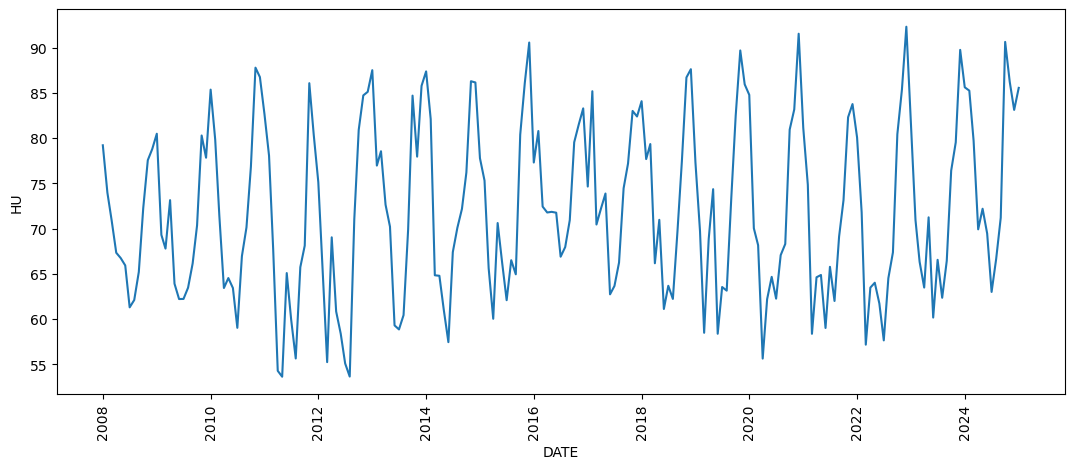

In [31]:
plt.figure(figsize=(13,5))
sns.lineplot(data=df_media_HU,x=df_media_HU.index,y=df_media_HU.HU)
plt.xticks(rotation=90)
plt.show()

### Precipitaciones medias mensuales en Italia

In [32]:
#Roma Ciampino
data=pd.read_csv("./tiempo/Italy/RR_ROMA_CIAMPINO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_roma=df.resample('MS').mean()

#Ferrara
data=pd.read_csv("./tiempo/Italy/RR_FERRARA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_ferrara=df.resample('MS').mean()

#Bologna
data=pd.read_csv("./tiempo/Italy/RR_BOLOGNA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_bologna=df.resample('MS').mean()

#Mantova
data=pd.read_csv("./tiempo/Italy/RR_MANTOVA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_mantova=df.resample('MS').mean()

#Milan
data=pd.read_csv("./tiempo/Italy/RR_MILAN.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_milan=df.resample('MS').mean()

#Brindisi
data=pd.read_csv("./tiempo/Italy/RR_BRINDISI.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_brindisi=df.resample('MS').mean()

#Verona Villafranca
data=pd.read_csv("./tiempo/Italy/RR_VERONA_VILLAFRANCA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_RR!=9)]
df=data.loc[:,['DATE','RR']]
dataW = df.set_index('DATE', inplace=True)
df_verona=df.resample('MS').mean()

df_concat = pd.concat([df_ferrara, df_roma, df_bologna, df_mantova, df_milan, df_brindisi,df_verona], axis=0)
df_media_RR = df_concat.groupby(level=0).mean()
#df_media_RR

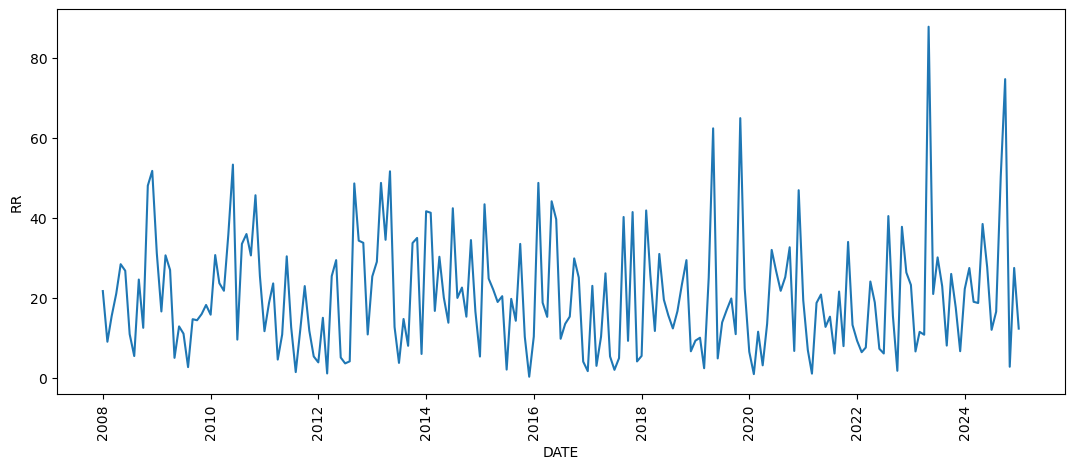

In [33]:
plt.figure(figsize=(13,5))
sns.lineplot(data=df_media_RR,x=df_media_RR.index,y=df_media_RR.RR)
plt.xticks(rotation=90)
plt.show()

### Fuerza media mensual del viento en Italia

In [34]:
#Roma Ciampino
data=pd.read_csv("./tiempo/Italy/FG_ROMA_CIAMPINO.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_roma=df.resample('MS').mean()

#Ferrara
data=pd.read_csv("./tiempo/Italy/FG_FERRARA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_ferrara=df.resample('MS').mean()

#Genoa
data=pd.read_csv("./tiempo/Italy/FG_GENOA.txt", sep=",")
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
df=data.loc[:,['DATE','FG']]
dataW = df.set_index('DATE', inplace=True)
df_genoa=df.resample('MS').mean()

df_concat = pd.concat([df_roma, df_ferrara,df_genoa], axis=0)
df_media_FG = df_concat.groupby(level=0).mean()
#df_media_FG

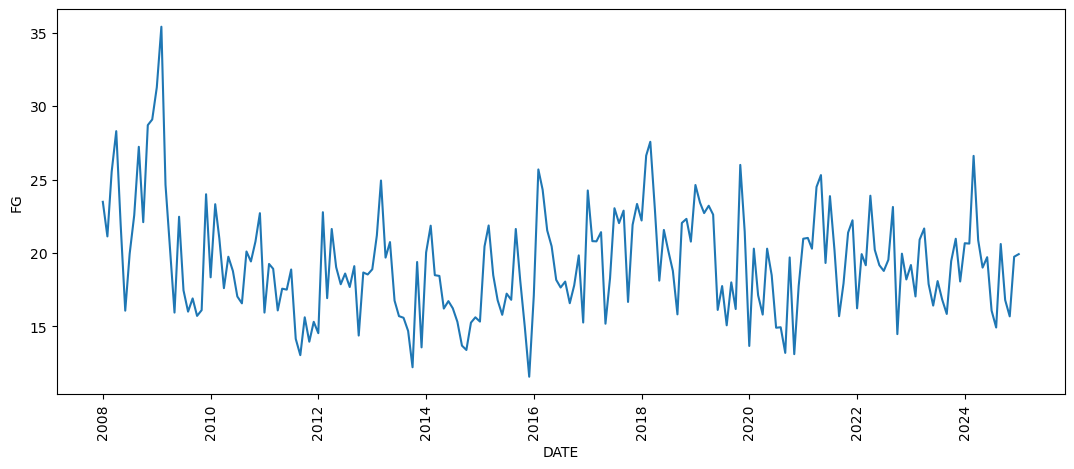

In [35]:
plt.figure(figsize=(13,5))
sns.lineplot(data=df_media_FG,x=df_media_FG.index,y=df_media_FG.FG)
plt.xticks(rotation=90)
plt.show()

### Unificación de dataframes

In [36]:
met=pd.concat([df_media_TG,df_media_HU,df_media_RR,df_media_FG],axis=1)
nilo=pd.concat([it,met],axis=1)
nilo=nilo.dropna()
#nilo

In [37]:
#nilo.to_csv('nilo_it_index.csv', index=True, encoding='utf-8')